# Store-Visit Visualizations and Interpretations

**Rice University Urban Sustainability Hackathon – FinalFlow**  
**Author workspace:** Hai Nam  
**Status:** Executed from top to bottom

This notebook consolidates the code, plots, and concise interpretations for the
store-visit visualization deliverable. It uses compact summary tables derived
from the Step-2 cleaned dataset, so it does not need to load the approximately
5.2 GB clean Parquet during normal review.

The analysis covers brands, categories, weekdays, visit distributions, monthly
patterns, and markets. Store visits are a transformed commercial-activity proxy;
they are not World Cup attendance, pedestrian counts, transit ridership, or a
causal forecast.


## 1. Setup

The first cell imports the libraries, finds the repository root, defines a
consistent visual style, and creates two small formatting helpers. Relative
repository paths make the notebook portable within the project.


In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import pandas as pd


def find_repository_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "summaries" / "summary_statistics.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from inside the RiceHack repository; "
        "data/summaries/summary_statistics.csv was not found."
    )


REPOSITORY_ROOT = find_repository_root()
SUMMARY_DIR = REPOSITORY_ROOT / "data" / "summaries"

RICE_BLUE = "#00205B"
MID_BLUE = "#4C78A8"
RICE_GOLD = "#C69214"
WEEKEND_ORANGE = "#E07A5F"
TEAL = "#2A9D8F"
GRID = "#D9DEE7"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.titlesize": 15,
        "font.size": 10,
    }
)


def wrap_labels(values, width=31):
    return [textwrap.fill(str(value), width=width) for value in values]


def clean_axis(axis):
    axis.grid(axis="x", color=GRID, linewidth=0.8, alpha=0.75)
    axis.set_axisbelow(True)


print(f"Repository root: {REPOSITORY_ROOT}")
print(f"Summary directory: {SUMMARY_DIR}")


Repository root: C:\Users\1\Documents\Rice_hack\RiceHack
Summary directory: C:\Users\1\Documents\Rice_hack\RiceHack\data\summaries


## 2. Load and validate prepared summaries

Only small, version-controlled summary CSVs are loaded. The assertions verify
that the expected columns exist and that all records are explicitly labeled as
`derived`.


In [2]:
summary = pd.read_csv(SUMMARY_DIR / "summary_statistics.csv").iloc[0]
percentiles = pd.read_csv(SUMMARY_DIR / "visit_percentiles.csv").iloc[0]
brands = pd.read_csv(SUMMARY_DIR / "visits_by_brand.csv")
categories = pd.read_csv(SUMMARY_DIR / "visits_by_category.csv")
weekdays = pd.read_csv(SUMMARY_DIR / "weekday_patterns.csv")
monthly = pd.read_csv(SUMMARY_DIR / "monthly_trends.csv", parse_dates=["month"])
markets = pd.read_csv(SUMMARY_DIR / "visits_by_market.csv")

required_metrics = {
    "total_visits", "record_count", "unique_stores", "mean_daily_visits", "data_type"
}
for name, table in {
    "brands": brands,
    "categories": categories,
    "weekdays": weekdays,
    "monthly": monthly,
    "markets": markets,
}.items():
    missing = required_metrics - set(table.columns)
    assert not missing, f"{name} is missing columns: {sorted(missing)}"
    assert set(table["data_type"]) == {"derived"}, f"{name} has invalid data labels"

coverage = pd.DataFrame(
    {
        "Measure": [
            "Store-day records", "Unique stores", "Brands", "Categories",
            "Markets", "Date range", "Mean visits/store-day", "Median visits/store-day"
        ],
        "Value": [
            f"{int(summary.total_rows):,}",
            f"{int(summary.unique_stores):,}",
            f"{int(summary.unique_brands):,}",
            f"{int(summary.unique_categories):,}",
            f"{int(summary.unique_markets):,}",
            f"{summary.earliest_date} to {summary.latest_date}",
            f"{float(summary.mean_daily_visits):,.2f}",
            f"{int(summary.median_daily_visits):,}",
        ],
    }
)
print(coverage.to_string(index=False))


                Measure                    Value
      Store-day records              223,342,163
          Unique stores                  143,574
                 Brands                    5,036
             Categories                      132
                Markets                        9
             Date range 2020-01-01 to 2024-12-31
  Mean visits/store-day                   620.77
Median visits/store-day                      199


## 3. Top brands by total transformed visits

The horizontal ranking makes long brand names readable and shows the total
commercial-activity scale of each leading brand.


notebook-cell-3:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


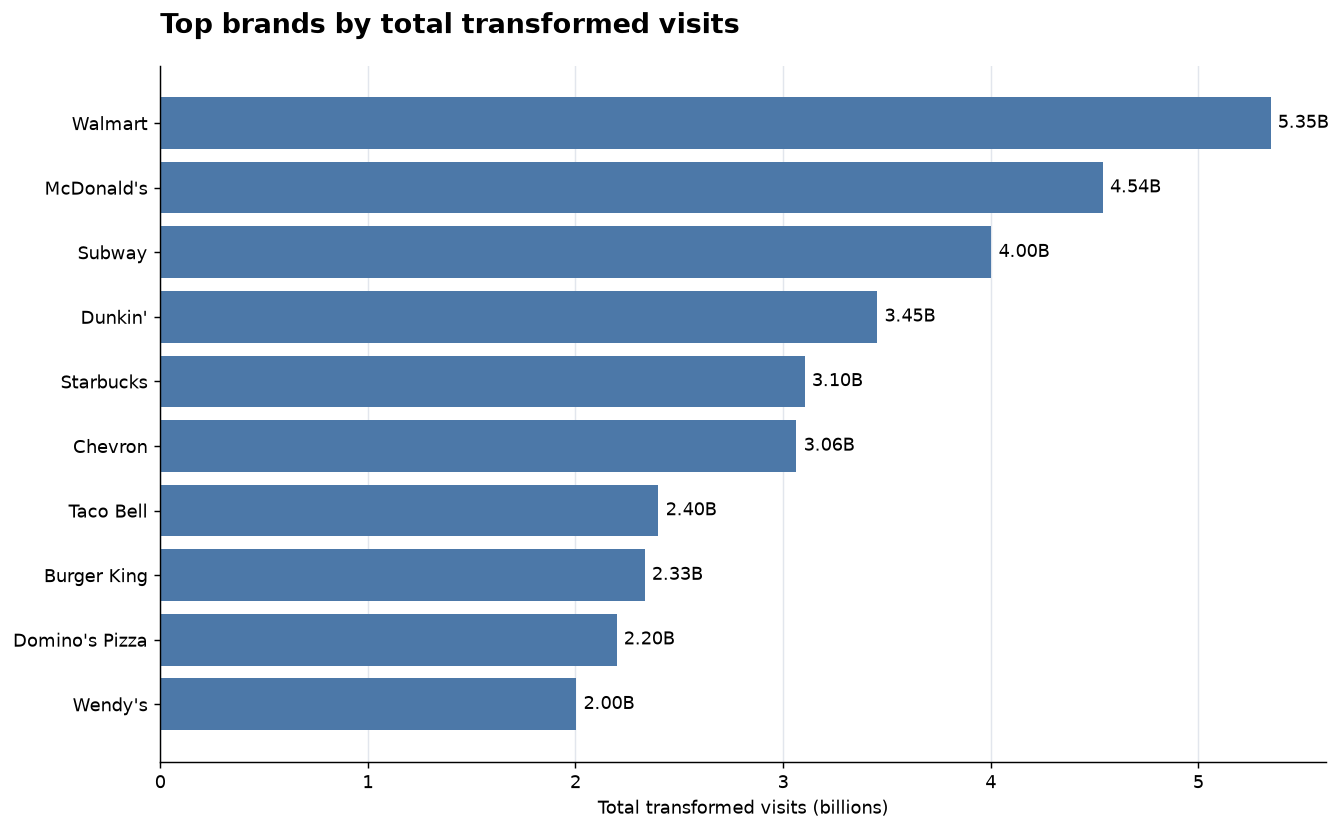

In [3]:
top_brands = (
    brands.nlargest(10, "total_visits")
    .sort_values("total_visits")
    .copy()
)
top_brands["total_billions"] = top_brands["total_visits"] / 1_000_000_000

fig, ax = plt.subplots(figsize=(10.5, 6.5))
bars = ax.barh(top_brands["brand"], top_brands["total_billions"], color=MID_BLUE)
ax.set_title("Top brands by total transformed visits", loc="left", pad=18)
ax.set_xlabel("Total transformed visits (billions)")
clean_axis(ax)
ax.bar_label(bars, labels=[f"{value:.2f}B" for value in top_brands["total_billions"]], padding=4)
fig.tight_layout()
plt.show()


### Interpretation

- **Walmart** ranks first among brands at approximately **5.35 billion
  transformed visits**.
- Its result reflects both its 368-store footprint and its mean activity of
  about 8,043.57 visits per store-day.
- A total ranking combines footprint and intensity; it does not show that a
  brand causes higher mobility demand.


## 4. Category scale versus daily intensity

Two panels prevent a large category footprint from being confused with high
activity at the typical store-day record.


notebook-cell-4:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


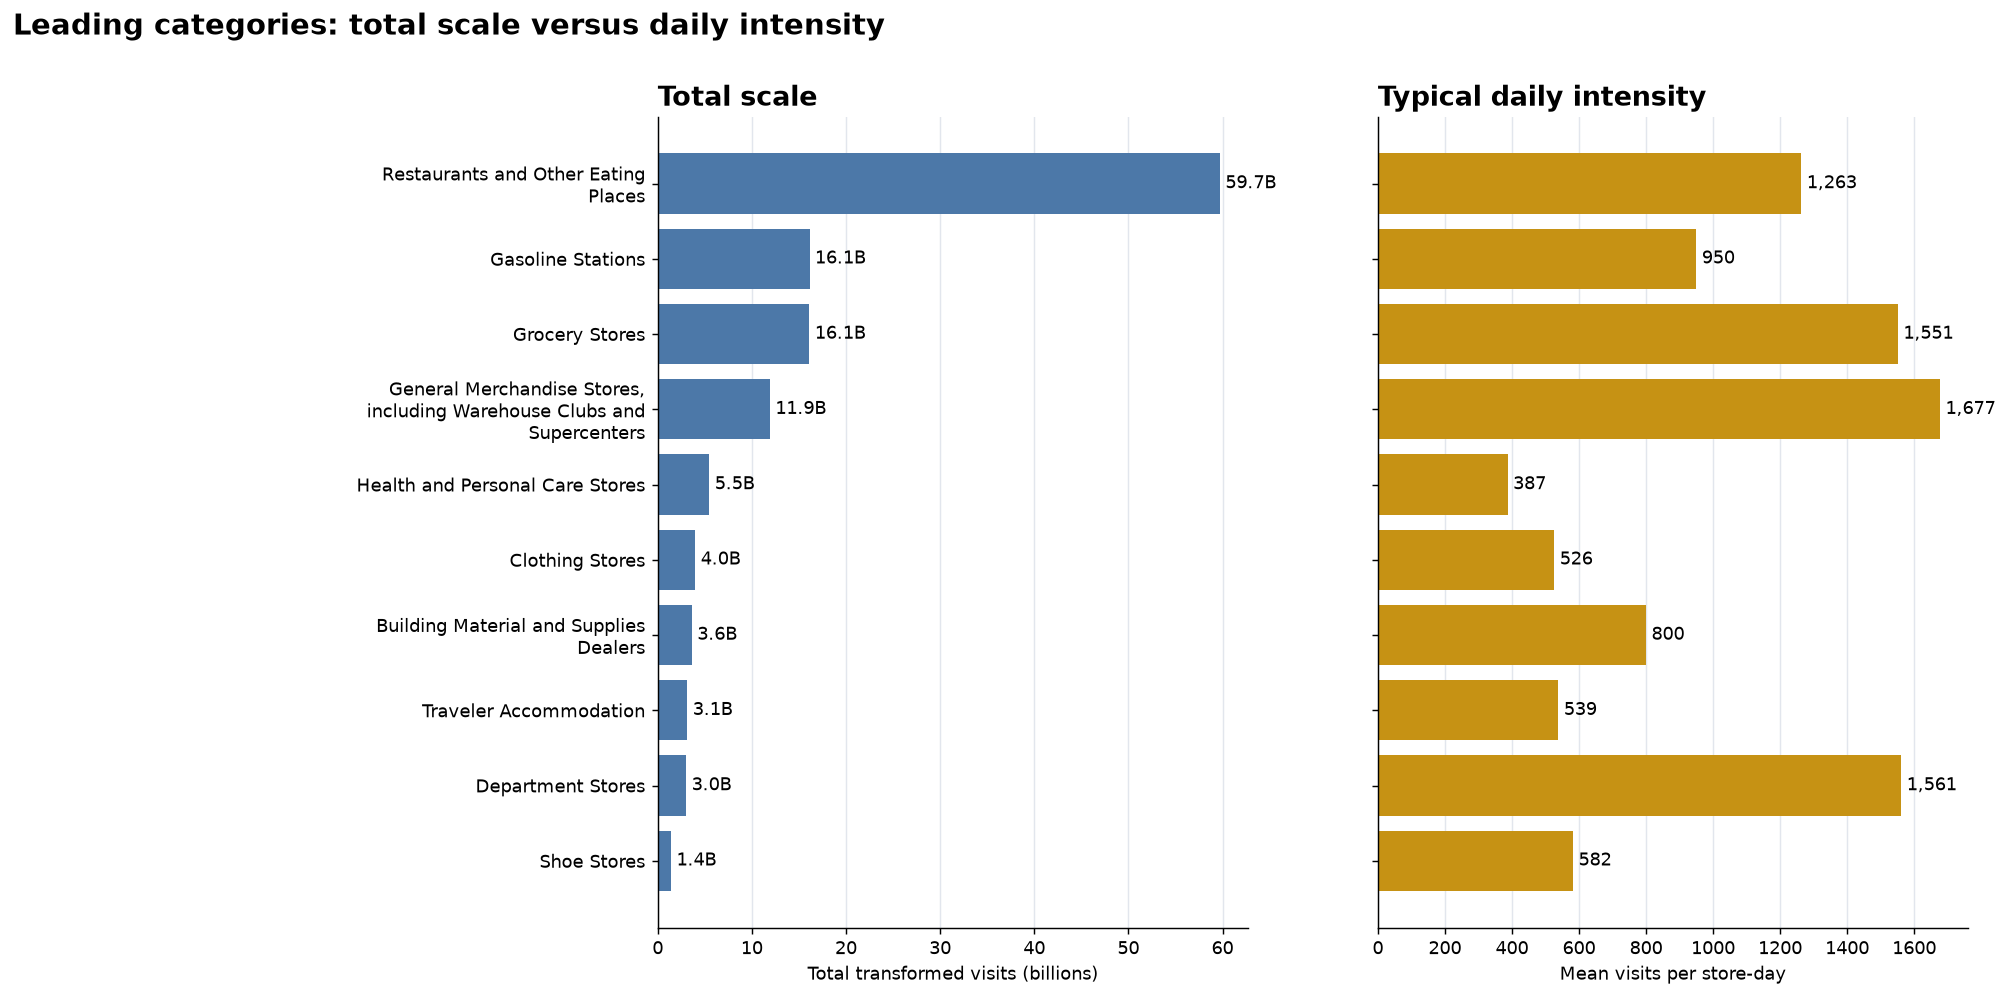

In [4]:
top_categories = categories.nlargest(10, "total_visits").sort_values("total_visits").copy()
labels = wrap_labels(top_categories["category"], width=34)
totals = top_categories["total_visits"] / 1_000_000_000
means = top_categories["mean_daily_visits"]

fig, (total_ax, mean_ax) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
total_bars = total_ax.barh(labels, totals, color=MID_BLUE)
mean_bars = mean_ax.barh(labels, means, color=RICE_GOLD)

total_ax.set_title("Total scale", loc="left")
total_ax.set_xlabel("Total transformed visits (billions)")
total_ax.bar_label(total_bars, labels=[f"{value:.1f}B" for value in totals], padding=3)

mean_ax.set_title("Typical daily intensity", loc="left")
mean_ax.set_xlabel("Mean visits per store-day")
mean_ax.bar_label(mean_bars, labels=[f"{value:,.0f}" for value in means], padding=3)

clean_axis(total_ax)
clean_axis(mean_ax)
fig.suptitle("Leading categories: total scale versus daily intensity", x=0.03, ha="left", fontsize=16, fontweight="bold")
fig.subplots_adjust(left=0.34, right=0.97, top=0.88, bottom=0.10, wspace=0.22)
plt.show()


### Interpretation

- **Restaurants and Other Eating Places** represents about **43.1%** of all
  transformed visits and dominates total category scale.
- Among the displayed leading categories, **General Merchandise Stores,
  including Warehouse Clubs and Supercenters** has the highest mean intensity
  at approximately **1,676.93 visits per store-day**.
- Total scale and typical daily intensity answer different business questions,
  so both should remain visible.


## 5. Weekday pattern

Mean visits per store-day are used because weekday record counts are nearly
equal. Weekend bars are highlighted separately.


notebook-cell-5:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


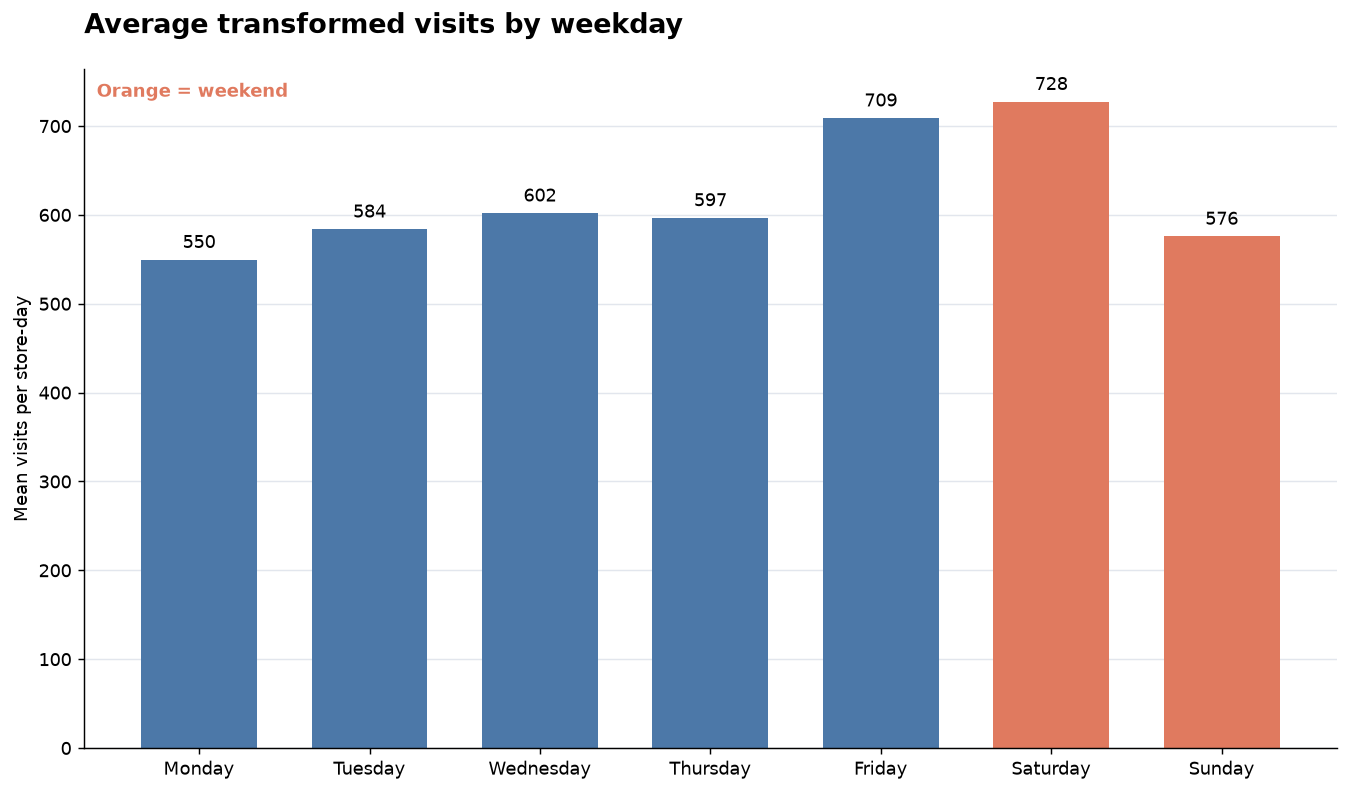

In [5]:
weekday_order = weekdays.sort_values("weekday_number")
colors = [WEEKEND_ORANGE if value else MID_BLUE for value in weekday_order["is_weekend"]]

fig, ax = plt.subplots(figsize=(10.5, 6.2))
bars = ax.bar(weekday_order["weekday"], weekday_order["mean_daily_visits"], color=colors, width=0.68)
ax.set_title("Average transformed visits by weekday", loc="left", pad=20)
ax.set_ylabel("Mean visits per store-day")
ax.grid(axis="y", color=GRID, linewidth=0.8, alpha=0.75)
ax.set_axisbelow(True)
ax.bar_label(bars, labels=[f"{value:,.0f}" for value in weekday_order["mean_daily_visits"]], padding=4)
ax.text(0.01, 0.98, "Orange = weekend", transform=ax.transAxes, va="top", color=WEEKEND_ORANGE, fontweight="bold")
fig.tight_layout()
plt.show()


### Interpretation

- **Saturday** is highest at about **727.60 mean visits per store-day**;
  **Monday** is lowest at about **549.77**.
- The highest weekday is approximately **32.3% above** the lowest weekday.
- This describes a recurring historical pattern, not the cause of the difference.


## 6. Visit distribution

The selected percentiles summarize the right-skewed distribution without
requiring a scan of the full clean Parquet. A logarithmic y-axis keeps both the
middle and upper tail readable.


notebook-cell-6:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


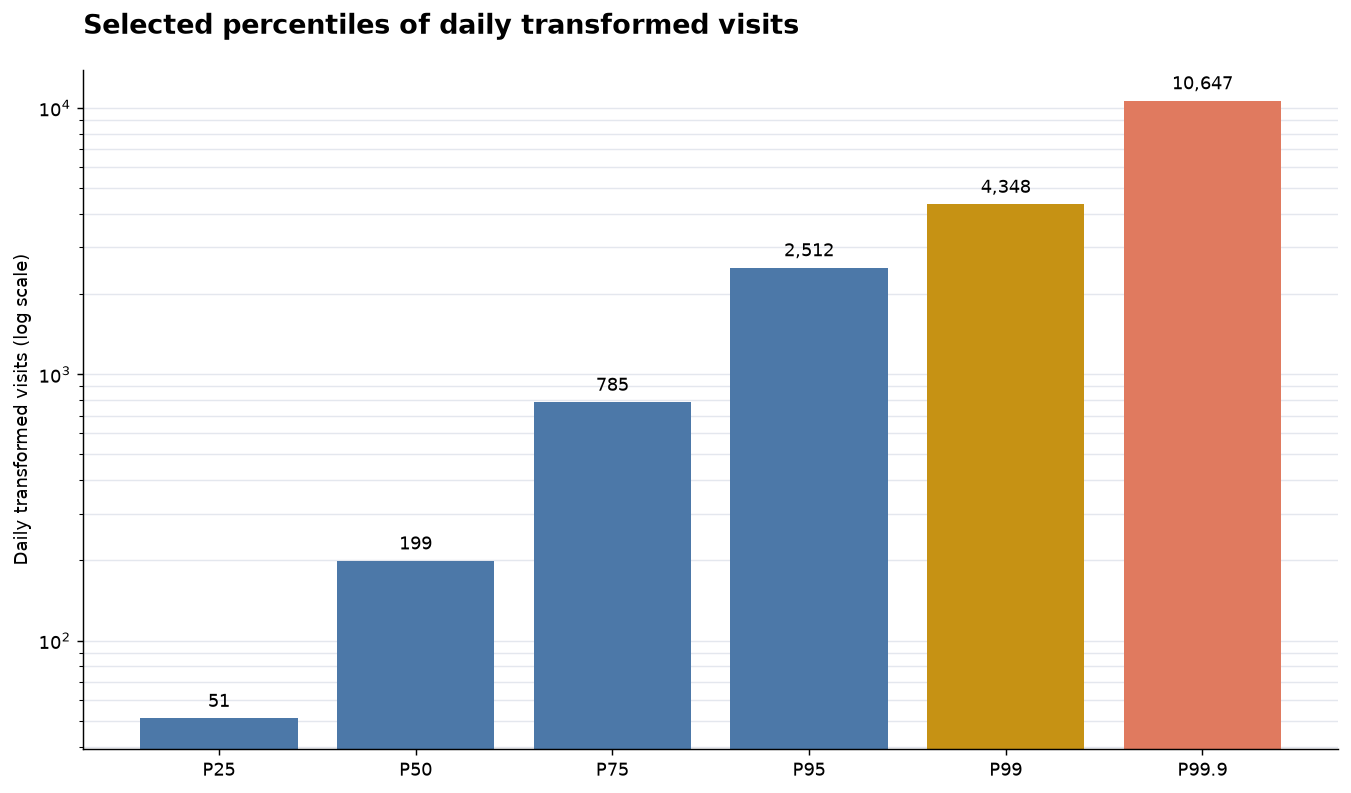

In [6]:
percentile_labels = ["P25", "P50", "P75", "P95", "P99", "P99.9"]
percentile_columns = ["p25", "p50", "p75", "p95", "p99", "p999"]
percentile_values = [int(percentiles[column]) for column in percentile_columns]

fig, ax = plt.subplots(figsize=(10.5, 6.2))
bars = ax.bar(
    percentile_labels,
    percentile_values,
    color=[MID_BLUE, MID_BLUE, MID_BLUE, MID_BLUE, RICE_GOLD, WEEKEND_ORANGE],
)
ax.set_yscale("log")
ax.set_title("Selected percentiles of daily transformed visits", loc="left", pad=20)
ax.set_ylabel("Daily transformed visits (log scale)")
ax.grid(axis="y", which="both", color=GRID, linewidth=0.8, alpha=0.70)
ax.set_axisbelow(True)
ax.bar_label(bars, labels=[f"{value:,}" for value in percentile_values], padding=4)
fig.tight_layout()
plt.show()


### Interpretation

- The median is **199**, well below the mean of **620.77**, confirming a
  strongly right-skewed distribution.
- **8.31%** of store-day records have zero visits; these records were retained.
- P99 is **4,348** and P99.9 is **10,647**. Values above P99.9 are review
  candidates, not automatically invalid observations.


## 7. Monthly historical trend

This notebook shows the mean-intensity view as a static executed output. The
standalone Plotly version in `reports/interactive/store_visits_monthly_trend.html`
adds hover details, a range slider, and a total/mean selector.


notebook-cell-7:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


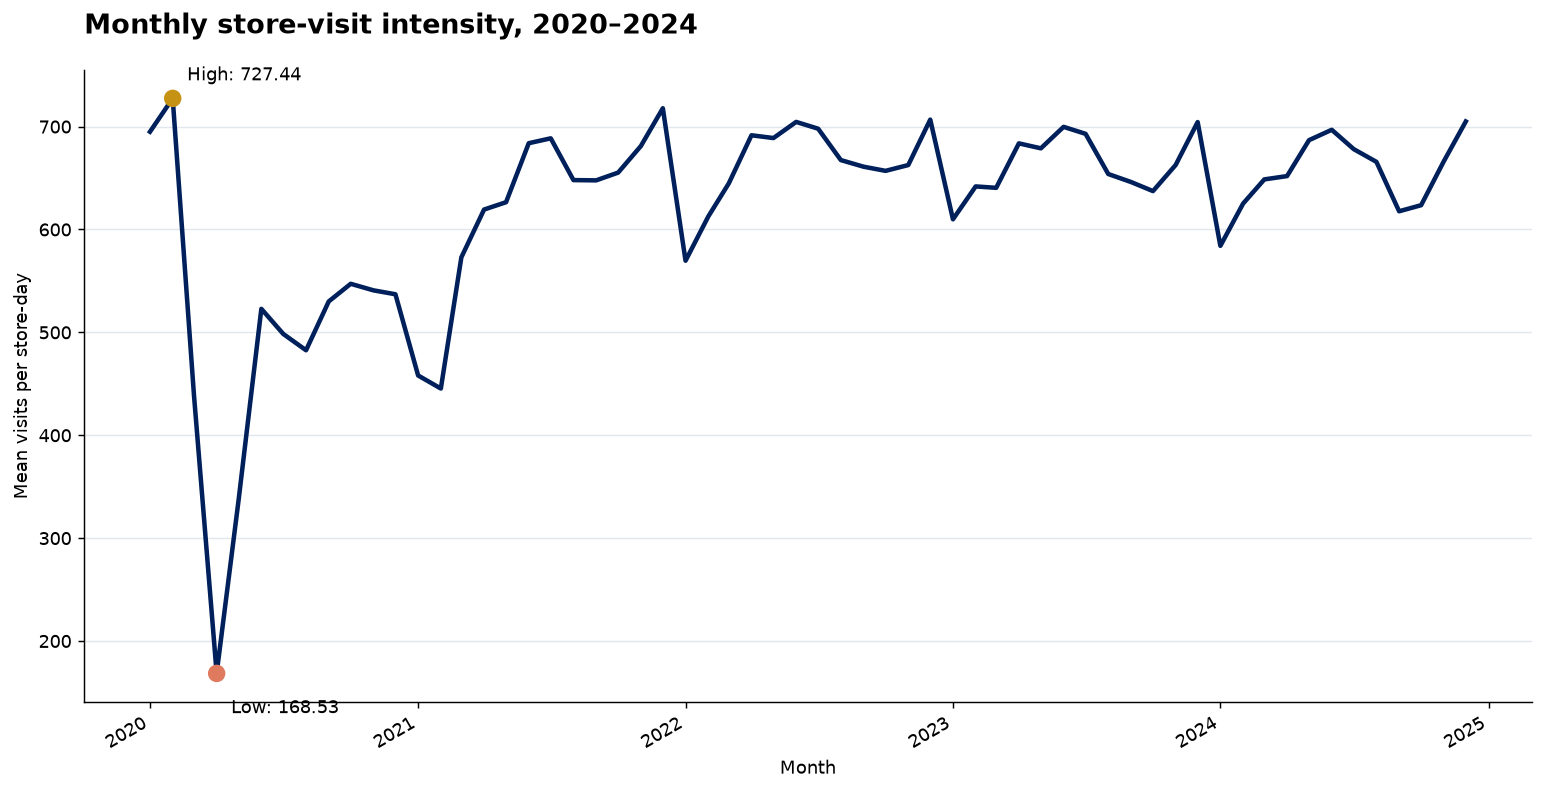

In [7]:
monthly_order = monthly.sort_values("month")
low_month = monthly_order.loc[monthly_order["mean_daily_visits"].idxmin()]
high_month = monthly_order.loc[monthly_order["mean_daily_visits"].idxmax()]

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.plot(monthly_order["month"], monthly_order["mean_daily_visits"], color=RICE_BLUE, linewidth=2.5)
ax.scatter([low_month["month"], high_month["month"]], [low_month["mean_daily_visits"], high_month["mean_daily_visits"]], color=[WEEKEND_ORANGE, RICE_GOLD], s=75, zorder=3)
ax.annotate(f"Low: {low_month['mean_daily_visits']:.2f}", (low_month["month"], low_month["mean_daily_visits"]), xytext=(8, -22), textcoords="offset points")
ax.annotate(f"High: {high_month['mean_daily_visits']:.2f}", (high_month["month"], high_month["mean_daily_visits"]), xytext=(8, 10), textcoords="offset points")
ax.set_title("Monthly store-visit intensity, 2020–2024", loc="left", pad=20)
ax.set_ylabel("Mean visits per store-day")
ax.set_xlabel("Month")
ax.grid(axis="y", color=GRID, linewidth=0.8, alpha=0.75)
ax.set_axisbelow(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


### Interpretation

- The lowest monthly mean is **168.53 in April 2020**; the highest is **727.44
  in February 2020**.
- Mean activity removes the calendar-length effect that influences monthly
  totals.
- The timing is visible, but the store-visit dataset alone cannot prove what
  caused a rise or decline.


## 8. Market scale versus daily intensity

The x-axis measures typical store-day intensity, the y-axis measures total
commercial scale, and bubble area represents unique stores. The standalone
Plotly version is `reports/interactive/store_visits_market_comparison.html`.


notebook-cell-8:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


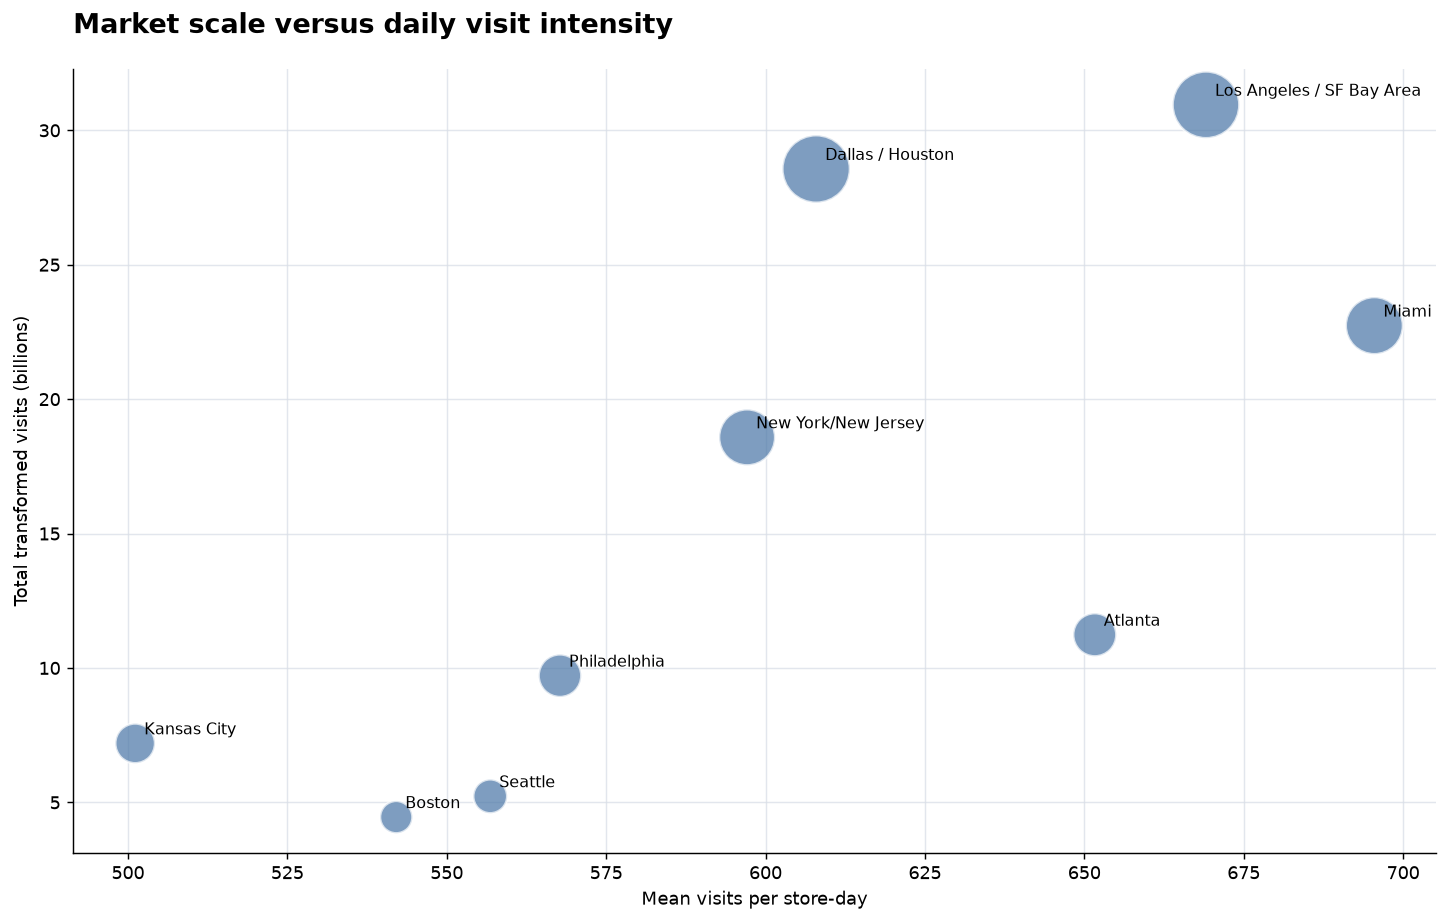

In [8]:
market_order = markets.sort_values("total_visits", ascending=False).copy()
market_order["total_billions"] = market_order["total_visits"] / 1_000_000_000
max_stores = market_order["unique_stores"].max()
bubble_areas = 100 + market_order["unique_stores"] / max_stores * 1_300

fig, ax = plt.subplots(figsize=(11.5, 7.2))
ax.scatter(
    market_order["mean_daily_visits"],
    market_order["total_billions"],
    s=bubble_areas,
    color=MID_BLUE,
    alpha=0.72,
    edgecolor="white",
    linewidth=1.4,
)
for row in market_order.itertuples():
    ax.annotate(row.market, (row.mean_daily_visits, row.total_billions), xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_title("Market scale versus daily visit intensity", loc="left", pad=20)
ax.set_xlabel("Mean visits per store-day")
ax.set_ylabel("Total transformed visits (billions)")
ax.grid(color=GRID, linewidth=0.8, alpha=0.75)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


### Interpretation

- **Los Angeles / SF Bay Area** has the largest total at approximately **30.95
  billion transformed visits**.
- **Miami** has the highest mean daily intensity at approximately **695.49
  visits per store-day**.
- Bubble area separates market footprint from per-record intensity. Combined
  market labels must not be interpreted as single cities.


## 9. Final conclusions and limitations

The visualizations establish transparent historical baselines for commercial
activity across business groups, time, weekdays, and markets. They can support
dashboard prioritization and later scenario design.

Important limitations:

- Store visits are a transformed commercial-activity proxy.
- They do not measure stadium attendance, pedestrian flow, transit ridership,
  or exact future demand.
- The data covers 2020–2024 and does not identify causes.
- High totals can reflect a large footprint, high daily intensity, or both.
- Market labels are broad provided groupings rather than precise store locations.
- Later World Cup work should combine these baselines with approved event,
  transport, weather, and geographic information.

For a reproducibility check, restart the kernel and run all cells from top to
bottom. Every chart should appear directly below its code cell.
